#### 0) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats

#### 1) Configurations

In [2]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

tickers = ["AAPL", "META", "MSFT", "TSLA"]

# Load strategy and portfolio returns
df_strat = pd.read_parquet(output_dir / "strategy_returns_all.parquet")
df_port = pd.read_parquet(output_dir / "portfolio_returns.parquet")

# Combine into a single analysis dataframe
df_analysis = df_strat.copy()
df_analysis['Portfolio'] = df_port['Portfolio']

# Construct Buy and Hold Benchmarks from raw signals
bnh_returns = {}
for ticker in tickers:
    df_raw = pd.read_parquet(output_dir / f"signals_{ticker}.parquet")
    bnh_returns[ticker] = df_raw['Close'].pct_change()

df_bnh = pd.DataFrame(bnh_returns).dropna()
df_bnh['Portfolio'] = df_bnh.mean(axis=1)

# Align indices to ensure perfect date matching
common_index = df_analysis.index.intersection(df_bnh.index)
df_analysis = df_analysis.loc[common_index]
df_bnh = df_bnh.loc[common_index]

#### 2) Core Risk and Return Metric Functions

In [4]:
def calc_sharpe(returns, risk_free=0.0): # How much return do I make per unit vol?
    excess = returns - risk_free
    return (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() > 0 else 0

def calc_sortino(returns, risk_free=0.0): # How much return do I make per unit downside vol?
    excess = returns - risk_free
    downside = excess[excess < 0]
    down_std = downside.std()
    return (excess.mean() / down_std) * np.sqrt(252) if down_std > 0 else 0

def calc_max_drawdown(returns): # From my highest returns, what was my lowest value?
    cum_ret = (1 + returns).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    return drawdown.min()

def calc_calmar(returns): # How much return do I make annually per unit DD?
    ann_ret = (1 + returns.mean()) ** 252 - 1
    mdd = abs(calc_max_drawdown(returns))
    return ann_ret / mdd if mdd > 0 else 0

def calc_omega(returns, threshold=0.0): # How much prob-weighted gain do I make per unit of prob-weighted loss?
    excess = returns - threshold
    pos_sum = excess[excess > 0].sum()
    neg_sum = abs(excess[excess < 0].sum())
    return pos_sum / neg_sum if neg_sum > 0 else 0

def calc_var_cvar(returns, conf_level=0.05): # var - What is the worst loss I should expect 5% percent of times?
    hist_var = returns.quantile(conf_level)  # cvar - Given I am in my 5% worst, What is the average loss?
    cvar = returns[returns <= hist_var].mean()
    z_score = stats.norm.ppf(conf_level)
    param_var = returns.mean() + z_score * returns.std()
    return hist_var, param_var, cvar

def calc_tail_ratio(returns): # Are my +Tails larger than my -Tails?
    p95 = returns.quantile(0.95)
    p05 = abs(returns.quantile(0.05))
    return p95 / p05 if p05 > 0 else 0

#### 3) Drawdown & Benchmark Analysis Functions

In [9]:
def analyze_drawdowns(returns):
    cum_ret = (1 + returns).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    
    is_dd = drawdown < 0
    
    # Create unique IDs for every consecutive block of drawdown or non-drawdown
    group_ids = (is_dd != is_dd.shift()).cumsum()
    
    # Calculate the duration (number of days) for every single block
    block_durations = is_dd.groupby(group_ids).sum()
    
    # Identify which group IDs correspond to actual drawdown periods (where is_dd was True)
    drawdown_group_mask = is_dd.groupby(group_ids).first()
    
    # Filter for drawdown blocks only and compute their average duration
    drawdown_durations = block_durations[drawdown_group_mask]
    avg_duration = drawdown_durations.mean() if not drawdown_durations.empty else 0.0
    
    # Count the total number of days spent below specific drawdown thresholds
    count_5 = (drawdown < -0.05).sum()
    count_10 = (drawdown < -0.10).sum()
    count_15 = (drawdown < -0.15).sum()
    
    return avg_duration, count_5, count_10, count_15

def calc_benchmark_metrics(strat_returns, bnh_returns):
    active_return = ((1 + strat_returns.mean()) ** 252 - 1) - ((1 + bnh_returns.mean()) ** 252 - 1)
    tracking_error = (strat_returns - bnh_returns).std() * np.sqrt(252)
    info_ratio = active_return / tracking_error if tracking_error > 0 else 0
    return active_return, info_ratio

#### 4) Execute Metrics and Build Summary Table

In [10]:
results = {}

for col in df_analysis.columns:
    ret = df_analysis[col]
    bnh = df_bnh[col]
    
    hist_var, param_var, cvar = calc_var_cvar(ret)
    avg_dd_dur, c5, c10, c15 = analyze_drawdowns(ret)
    active_ret, ir = calc_benchmark_metrics(ret, bnh)
    
    results[col] = {
        'Annualized Return': (1 + ret.mean()) ** 252 - 1,
        'Annualized Volatility': ret.std() * np.sqrt(252),
        'Sharpe Ratio': calc_sharpe(ret),
        'Sortino Ratio': calc_sortino(ret),
        'Calmar Ratio': calc_calmar(ret),
        'Omega Ratio': calc_omega(ret),
        'Historical VaR (95%)': hist_var,
        'Parametric VaR (95%)': param_var,
        'CVaR (95%)': cvar,
        'Tail Ratio': calc_tail_ratio(ret),
        'Max Drawdown': calc_max_drawdown(ret),
        'Avg DD Duration (Days)': avg_dd_dur,
        'Days DD > 5%': c5,
        'Days DD > 10%': c10,
        'Days DD > 15%': c15,
        'Active Return vs BnH': active_ret,
        'Information Ratio': ir
    }

df_performance = pd.DataFrame(results)
df_performance.to_parquet(output_dir / "performance_summary.parquet")

print("Performance Summary Metrics")
print(df_performance.round(4))

Performance Summary Metrics
                             AAPL       META       MSFT       TSLA  Portfolio
Annualized Return          0.1542     0.1588     0.1079     0.4617     0.2132
Annualized Volatility      0.1742     0.2376     0.1771     0.3954     0.1644
Sharpe Ratio               0.8233     0.6205     0.5787     0.9607     1.1759
Sortino Ratio              0.8836     0.6872     0.6281     1.0240     1.4585
Calmar Ratio               0.5462     0.5633     0.4201     0.8223     0.9278
Omega Ratio                1.2106     1.1606     1.1367     1.2857     1.2636
Historical VaR (95%)      -0.0166    -0.0217    -0.0166    -0.0346    -0.0153
Parametric VaR (95%)      -0.0175    -0.0240    -0.0179    -0.0395    -0.0163
CVaR (95%)                -0.0270    -0.0350    -0.0279    -0.0569    -0.0241
Tail Ratio                 1.1269     1.0509     1.0951     1.1336     1.0590
Max Drawdown              -0.2823    -0.2819    -0.2568    -0.5615    -0.2298
Avg DD Duration (Days)    41.4615   

#### 5) Rolling Sharpe & DD plot

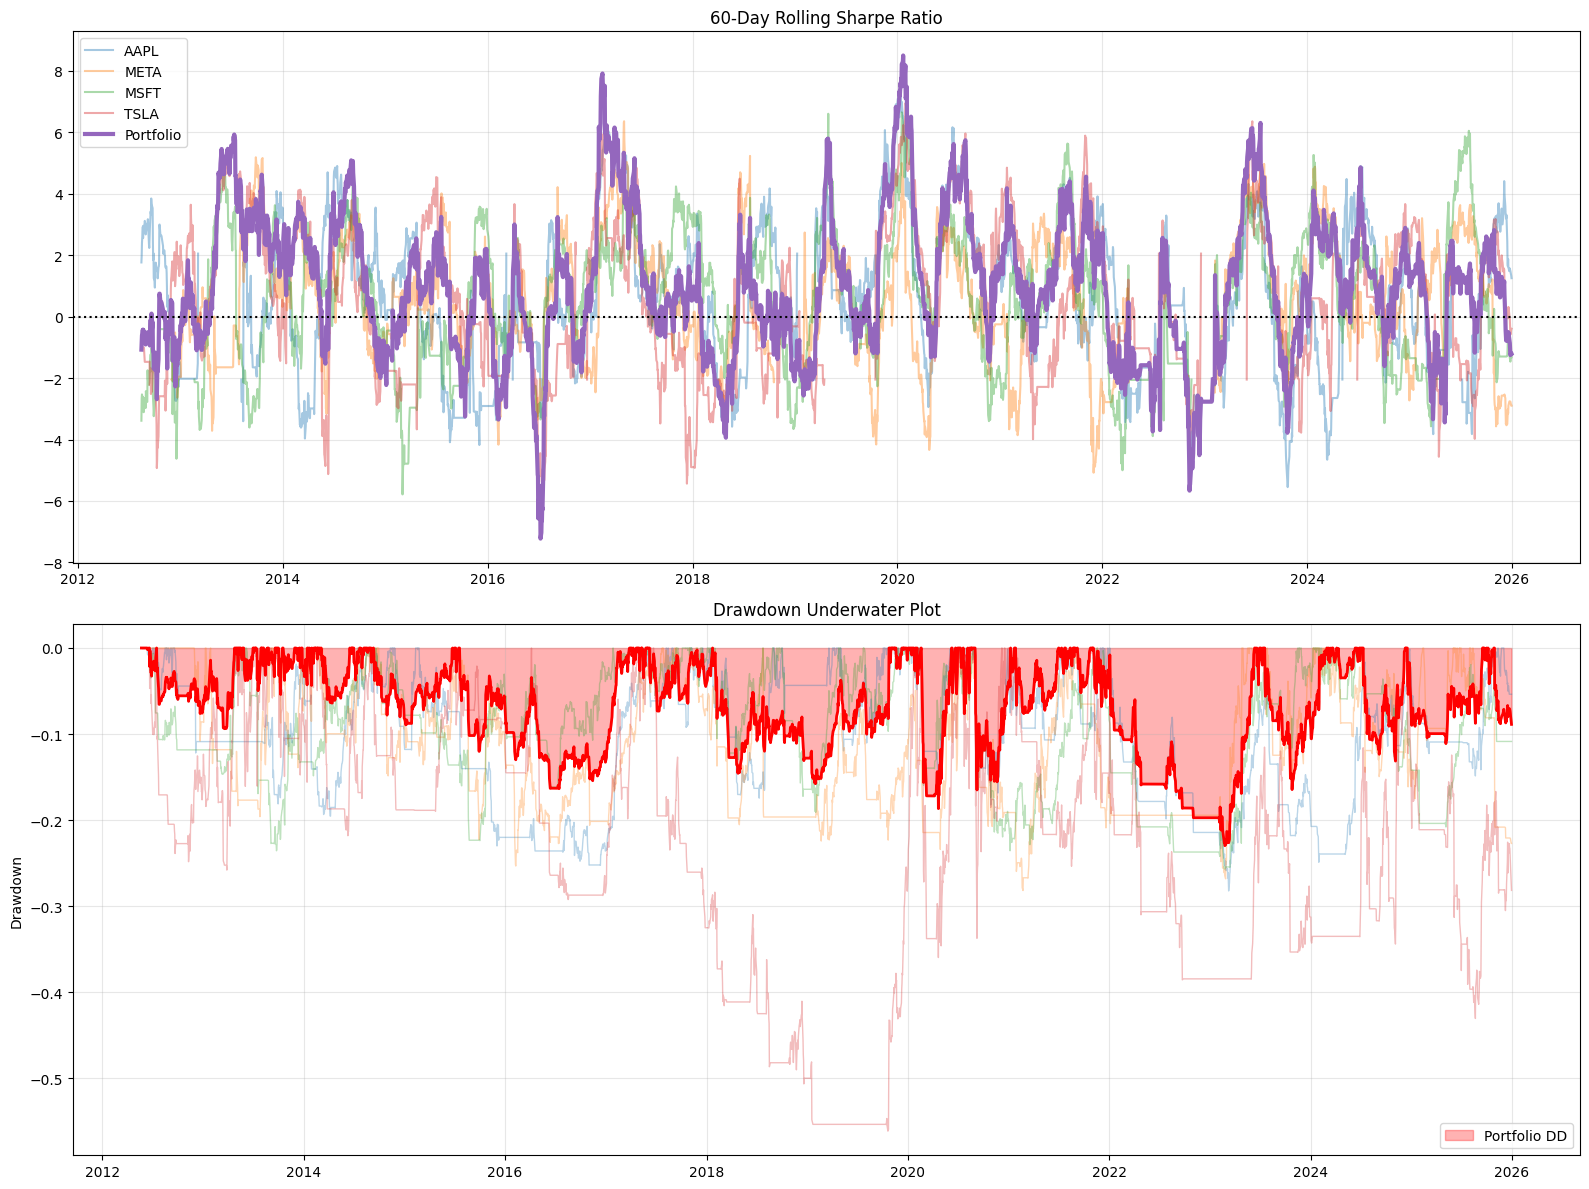

In [11]:
plt.figure(figsize=(16, 12))

# Subplot 1: 60-Day Rolling Sharpe Ratio
ax1 = plt.subplot(2, 1, 1)
rolling_sharpe = (df_analysis.rolling(60).mean() / df_analysis.rolling(60).std()) * np.sqrt(252)

for col in df_analysis.columns:
    lw = 3 if col == 'Portfolio' else 1.5
    alpha = 1.0 if col == 'Portfolio' else 0.4
    ax1.plot(rolling_sharpe.index, rolling_sharpe[col], label=col, linewidth=lw, alpha=alpha)

ax1.axhline(0, color='black', linestyle=':')
ax1.set_title("60-Day Rolling Sharpe Ratio")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: Drawdown Underwater Plot
ax2 = plt.subplot(2, 1, 2)
for col in df_analysis.columns:
    cum_ret = (1 + df_analysis[col]).cumprod()
    rolling_max = cum_ret.cummax()
    drawdown = (cum_ret - rolling_max) / rolling_max
    
    if col == 'Portfolio':
        ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3, label='Portfolio DD')
        ax2.plot(drawdown.index, drawdown, color='red', linewidth=2)
    else:
        ax2.plot(drawdown.index, drawdown, alpha=0.3, linewidth=1)

ax2.set_title("Drawdown Underwater Plot")
ax2.set_ylabel("Drawdown")
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 6) Returns Heatmap & Annual Bar Chart

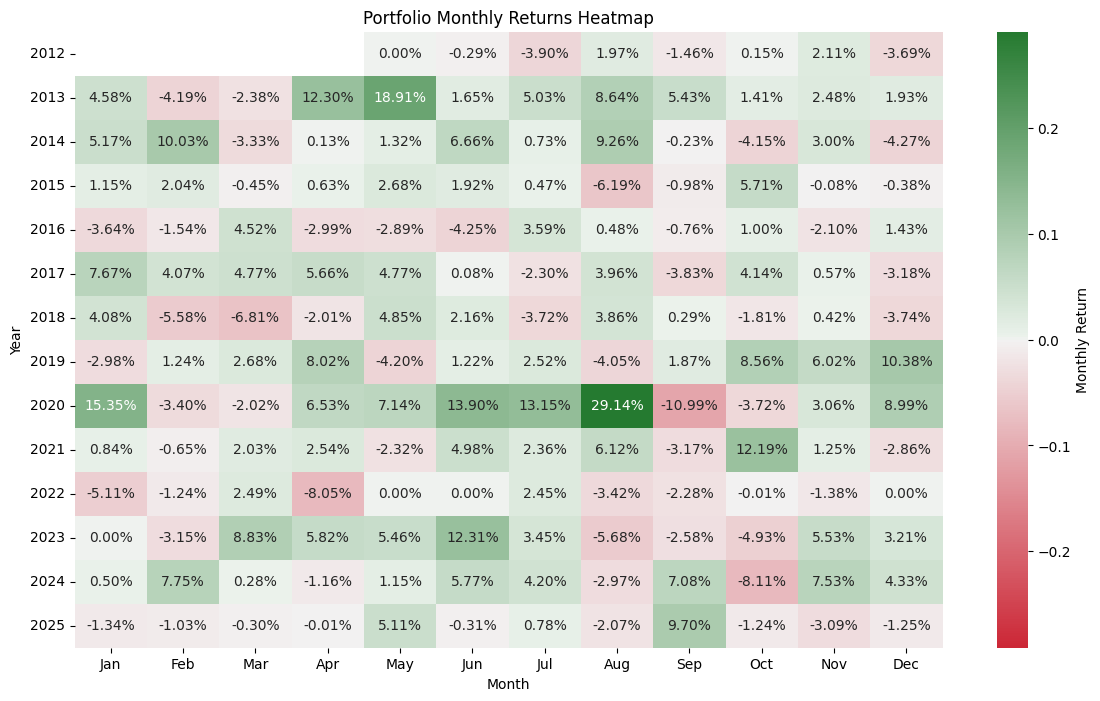

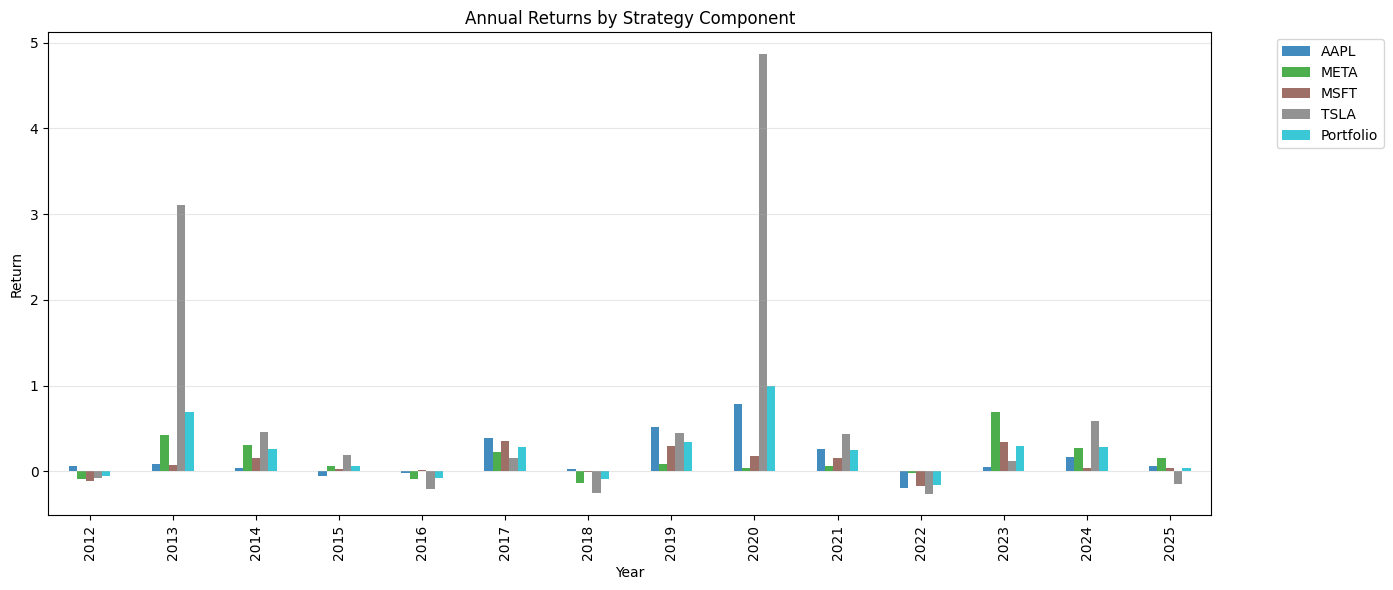

In [16]:
# Monthly Returns Heatmap for the Portfolio
port_ret = df_analysis['Portfolio']
monthly_ret = port_ret.resample('ME').apply(lambda x: (1 + x).prod() - 1)

heatmap_data = pd.DataFrame({
    'Year': monthly_ret.index.year,
    'Month': monthly_ret.index.strftime('%b'),
    'Return': monthly_ret.values
})

heatmap_pivot = heatmap_data.pivot(index='Year', columns='Month', values='Return')
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_pivot = heatmap_pivot.reindex(columns=[m for m in months_order if m in heatmap_pivot.columns])

# Find the maximum absolute value to create a perfectly balanced symmetric color scale
max_val = max(abs(heatmap_pivot.min().min()), abs(heatmap_pivot.max().max()))

# Create a crisp custom diverging palette: 10 is a vivid red, 130 is a vibrant green
custom_rdgr = sns.diverging_palette(10, 130, s=85, l=45, n=9, as_cmap=True)

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_pivot, 
    annot=True, 
    fmt=".2%", 
    cmap=custom_rdgr, 
    center=0, 
    vmin=-max_val, 
    vmax=max_val, 
    cbar_kws={'label': 'Monthly Return'}
)
plt.title("Portfolio Monthly Returns Heatmap")
plt.yticks(rotation=0)
plt.show()

# Annual Returns Component Breakdown
annual_strat = df_analysis.resample('YE').apply(lambda x: (1 + x).prod() - 1)
annual_strat.index = annual_strat.index.year

annual_strat.plot(kind='bar', figsize=(14, 6), colormap='tab10', alpha=0.85)
plt.title("Annual Returns by Strategy Component")
plt.ylabel("Return")
plt.xlabel("Year")
plt.grid(axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()